In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)

In [3]:
df = pd.read_csv('fmnist_small.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


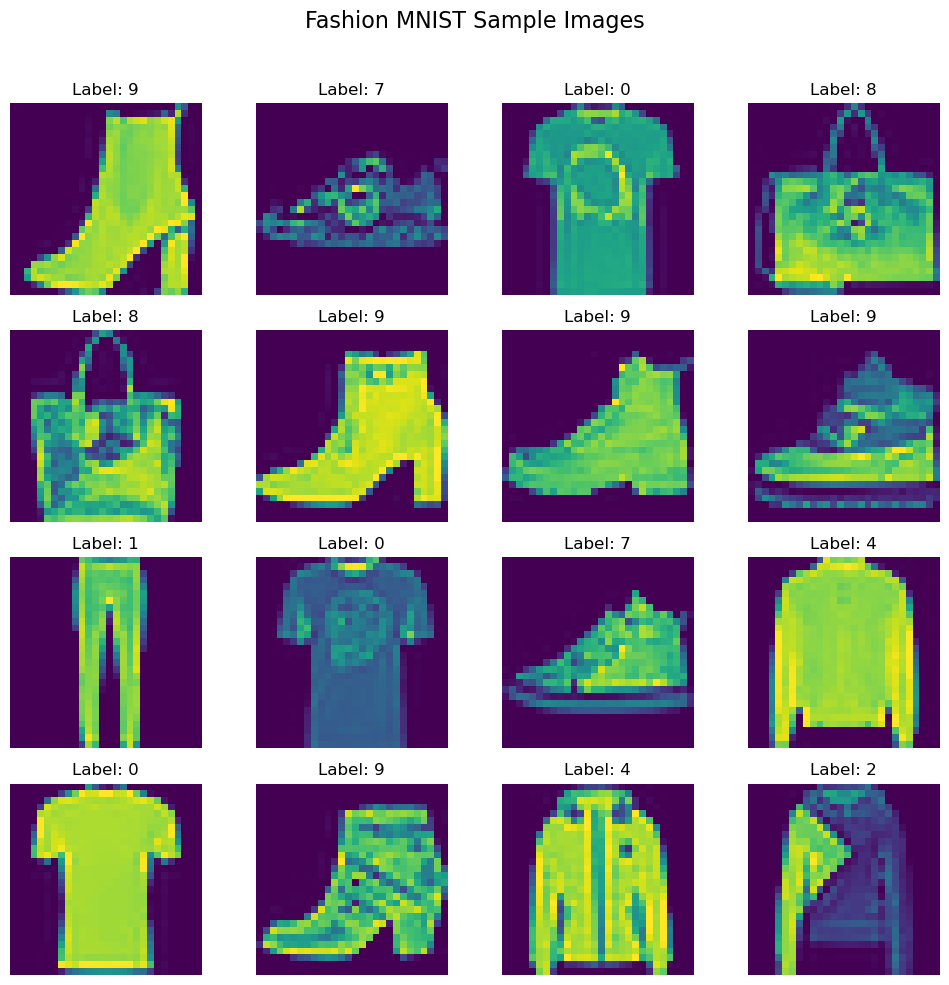

In [4]:
fig,axes = plt.subplots(nrows=4,ncols=4,figsize=(10,10))
fig.suptitle('Fashion MNIST Sample Images', fontsize=16)


for i, ax in enumerate(axes.flatten()):
    image = df.iloc[i, 1:].values.reshape(28, 28) 
    label = df.iloc[i, 0]  
    ax.imshow(image)  
    ax.set_title(f'Label: {label}') 
    ax.axis('off')  
    ax.set_xlabel(f"label : {df.iloc[i,0]}")
    
plt.tight_layout(rect=[0,0,1,0.96])  
plt.show()

In [5]:
X = df.iloc[:, 1:].values  
y = df.iloc[:, 0].values  

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [8]:
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.X = torch.tensor(features, dtype=torch.float32)  # convert to tensor
        self.y = torch.tensor(labels, dtype=torch.long)     # convert to tensor

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [9]:
train_dataset = CustomDataset(X_train, y_train)

In [10]:
test_dataset = CustomDataset(X_test, y_test)

In [11]:
len(train_dataset)
len(test_dataset)

1200

In [12]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [13]:
class SimpleNN(nn.Module):
    def __init__(self,num_features):
        super().__init__()  
        self.network = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.BatchNorm1d(128), #pichle layer se katne activation mil rahe hai
            nn.ReLU(), 
            nn.Dropout(p=0.3), # means what percent of neurons to drop during training
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(64, 10)  
        )

    def forward(self, x):
        return self.network(x)

- batch normalization he linear nantar ani activation chya aadhi lagte
- dropout he activation chya nantar lagte, dropout madhe p send karto jo tharvto ki kiti % neurons turn off karayche ahet
- regularization he loss function kiva optimizer chya madat tine use karata yete


In [14]:
learning_rate = 0.1
num_epochs = 100
#  in optimizers, we write the regularization term as weight_decay

In [15]:
model = SimpleNN(num_features=X_train.shape[1])

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate,weight_decay=1e-4)

In [16]:
# training loop
for epoch in range(num_epochs):
    model.train()  
    for batch_feature, batch_labels in train_loader:
        # forward pass
        outputs = model(batch_feature)
        
        # calculate loss
        loss = criterion(outputs, batch_labels)

        # backward pass and optimization
        optimizer.zero_grad()  # clear previous gradients
        loss.backward()        # compute gradients
        
        # update weights
        optimizer.step()       

    if (epoch+1) % 10 == 0:  # (batch wise loss can be massy, so we print every 10 epochs)
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.3700
Epoch [20/100], Loss: 0.2516
Epoch [30/100], Loss: 0.1794
Epoch [40/100], Loss: 0.0972
Epoch [50/100], Loss: 0.1781
Epoch [60/100], Loss: 0.0868
Epoch [70/100], Loss: 0.0367
Epoch [80/100], Loss: 0.1047
Epoch [90/100], Loss: 0.1341
Epoch [100/100], Loss: 0.1670


In [17]:
model.eval() 

SimpleNN(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [18]:
total = 0
correct = 0

# 
with torch.no_grad():
    for batch_feature, batch_labels in test_loader:
        outputs = model(batch_feature)
        _, predicted = torch.max(outputs.data, 1)
        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

print(f'Accuracy on the test set: {100 * correct / total:.2f}%')

Accuracy on the test set: 84.83%


In [19]:
# how to improve the model

# try out diff optimizers, learning rates, epochs
# try out diff nn architectures, add more layers, change activation functions, etc.
# hyperparameter tuning, regularization techniques, data augmentation, etc.

In [20]:
with torch.no_grad():
    for batch_feature, batch_labels in train_loader:
        outputs = model(batch_feature)
        _, predicted = torch.max(outputs.data, 1)
        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

print(f'Accuracy on the test set: {100 * correct / total:.2f}%')

Accuracy on the test set: 96.28%


In [ ]:
# test la 83 ani training la 97 ahe accuracy
# gap is 10 percent, which is a sign of overfitting.

# after adding batch normalization, test accuracy is 84 and training accuracy is 96, gap is reduced to 9 percent, which is a sign of reduced overfitting.
